In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from method import plot_multiple_wfms, plot_averaging, plot_wfm_fitting

sns.set_theme(style="ticks")

Load data

In [2]:
# filter point clould data to whitewater area of interest
whitewater_df = pd.read_csv("data\pielach_whitewater.txt", index_col=0)

# load waveform data from pickled dataframe
waveform_data_df = pd.read_pickle("data\waveform_data.df")

# get waveform data
waveform_data = waveform_data_df["wfm"].values

# adjust sensor coordinates to meter values for plotting
x_offset = np.abs(min(whitewater_df["x"].values))

In [3]:
wfm_amplitude_raw = np.array([np.max(wfm.T[1]) for wfm in waveform_data])

whitewater_df["raw_amplitude"] = wfm_amplitude_raw

sample_intervals = 5.025e-10

Plot data

Text(0, 1.05, 'A')

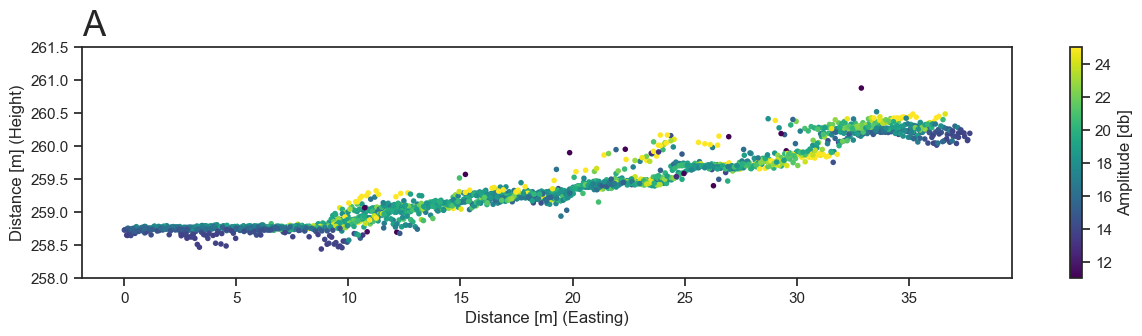

In [4]:
sns.set(rc={'figure.figsize':(15, 3)})
sns.set_theme(style="ticks")

# plot area of interest
ax = sns.scatterplot(x=whitewater_df["x"].values + x_offset, y=whitewater_df["z"].values,
                     hue=whitewater_df["amplitude"], hue_norm=(11, 25), palette="viridis", legend=False, linewidth=0, s=16)


# add a colorbar
cbar = ax.figure.colorbar(plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(11, 25)), ax=ax)

# add labels
ax.set_ylim(258, 261.5)
cbar.set_label("Amplitude [db]")
ax.set_xlabel("Distance [m] (Easting)")
ax.set_ylabel("Distance [m] (Height)")
ax.text(0, 1.05, "A", fontsize=25, transform=ax.transAxes)


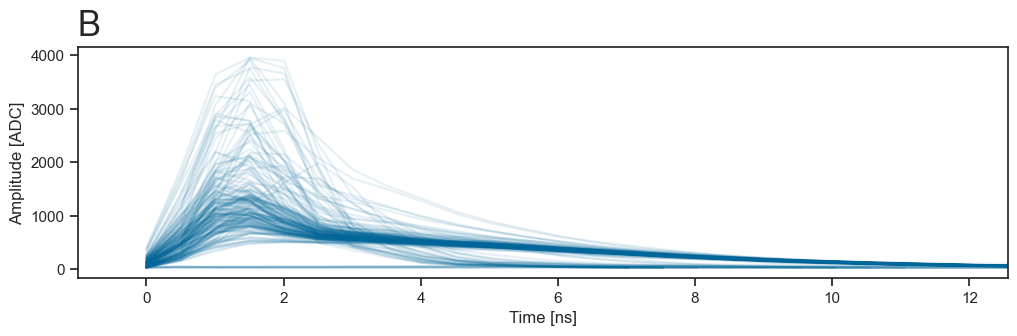

In [5]:
sns.set(rc={'figure.figsize':(12, 3)})
sns.set_theme(style="ticks")

ax, _ = plot_multiple_wfms(waveform_data[:500], "#006699", "B", sample_intervals)

Split waveform data by amplitude

In [6]:
lower_bounds = [0, 1000, 2000, 3000]
upper_bounds = [1000, 2000, 3000, np.inf]

wfm_data_list = []
for lower, upper in zip(lower_bounds, upper_bounds):
    
    mask = (whitewater_df["raw_amplitude"] > lower) & (whitewater_df["raw_amplitude"] <= upper)
    wfm_data_list.append(waveform_data[mask])


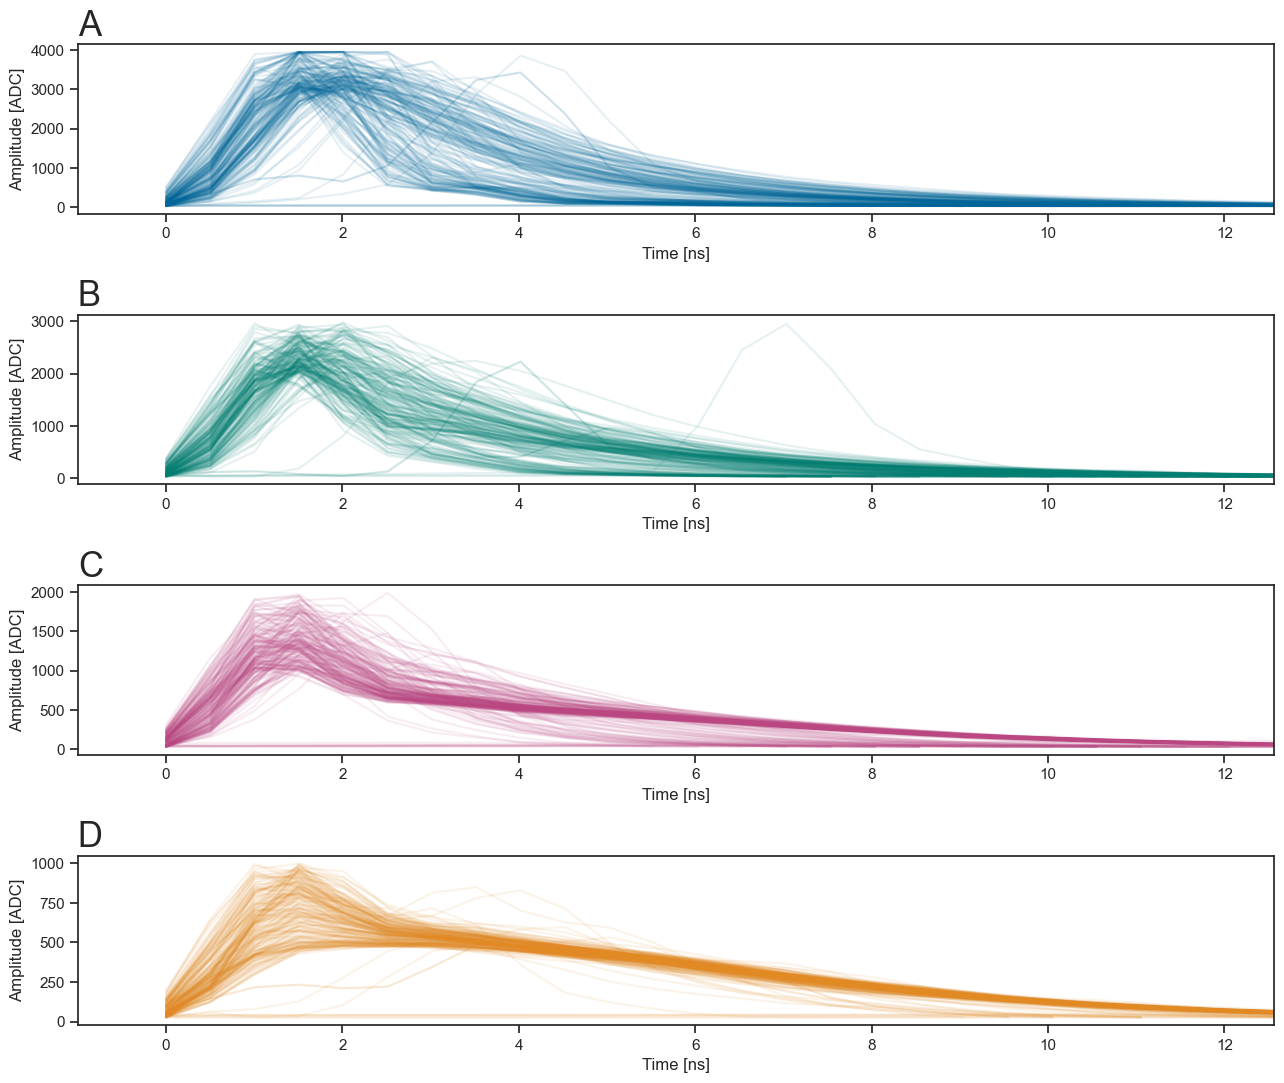

In [7]:
plt.figure(figsize=(13, 11))

plt.subplot(4, 1, 1)
ax, wfms_3000 = plot_multiple_wfms(wfm_data_list[3], "#006699", "A", sample_intervals)

plt.subplot(4, 1, 2)
ax, wfms_2000 = plot_multiple_wfms(wfm_data_list[2], "#007E71", "B", sample_intervals)

plt.subplot(4, 1, 3)
ax, wfms_1000 = plot_multiple_wfms(wfm_data_list[1], "#BA4682", "C", sample_intervals)

plt.subplot(4, 1, 4)
ax, wfms_0000 = plot_multiple_wfms(wfm_data_list[0], "#E18922", "D", sample_intervals)

plt.tight_layout()

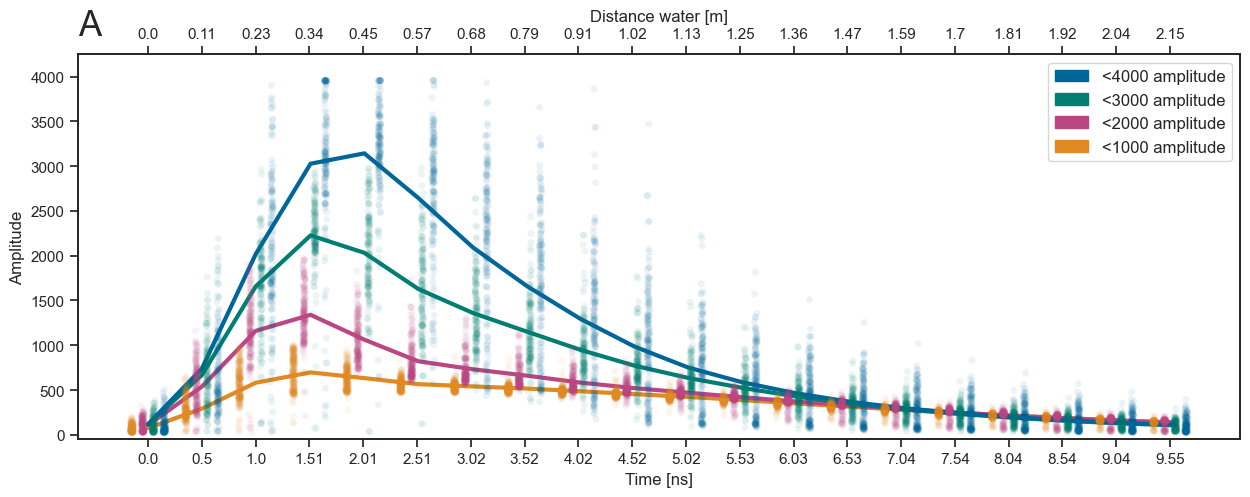

In [8]:
sns.set(rc={'figure.figsize':(15, 5)})
sns.set_theme(style="ticks")

def create_wfm_df(wfm_list, length, cols):
    """Converts a list of waveforms into a formatted DataFrame."""

    data = [wfm[:length] for wfm in wfm_list if len(wfm) > length]
    
    return pd.DataFrame(data, columns=cols)

# 
length_wfms = 20
cols = [np.round(i * sample_intervals * 1e9, 2) for i in range(length_wfms)]

# 
df_0_wfms     = create_wfm_df(wfms_0000, length_wfms, cols)
df_1000_wfms  = create_wfm_df(wfms_1000, length_wfms, cols)
df_2000_wfms  = create_wfm_df(wfms_2000, length_wfms, cols)
df_3000_wfms  = create_wfm_df(wfms_3000, length_wfms, cols)

#
plot_averaging(df_0_wfms, df_1000_wfms, df_2000_wfms, df_3000_wfms)

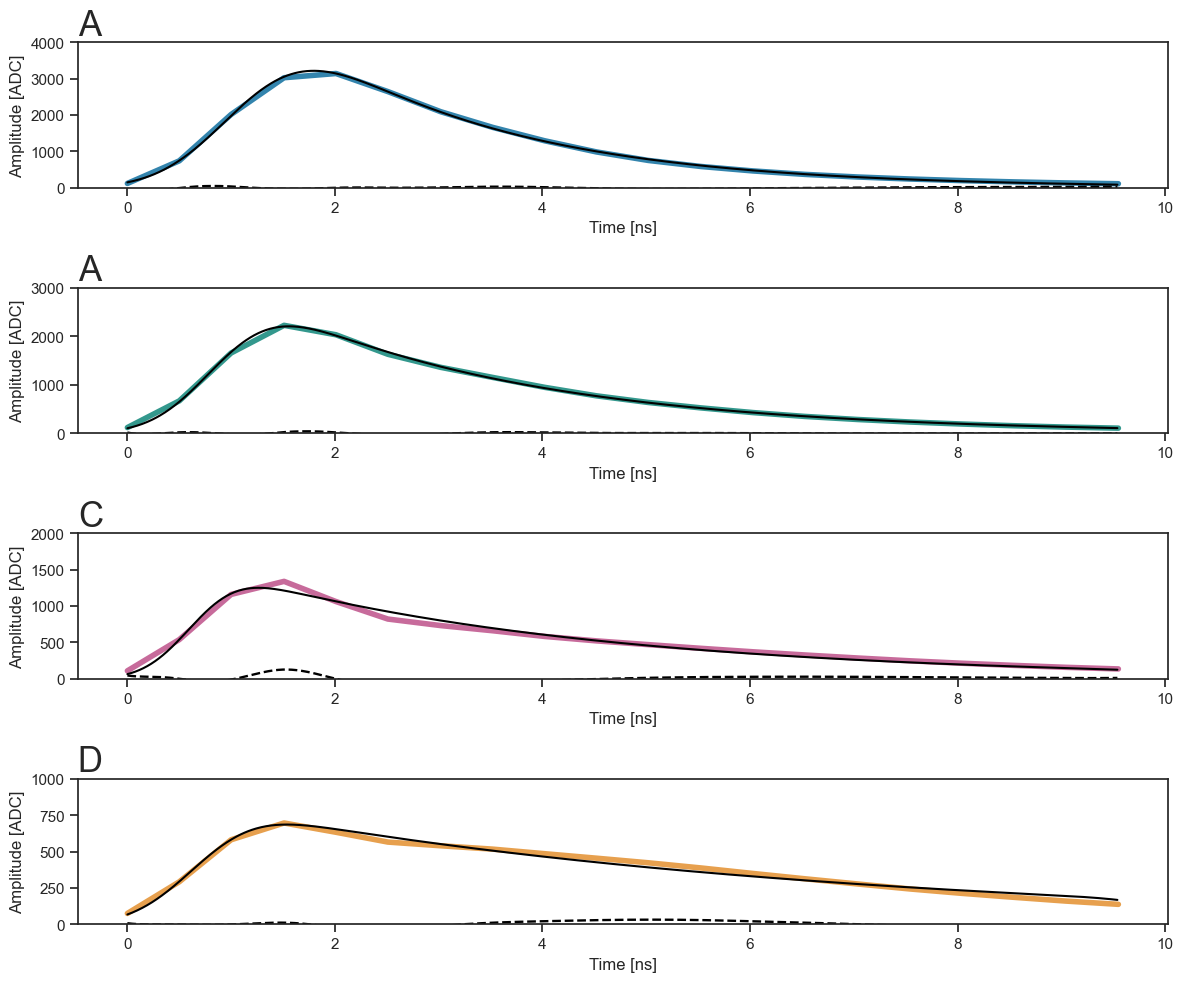

In [9]:
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plot_wfm_fitting(df_3000_wfms.mean().index, df_3000_wfms.mean().values, "A", "#006699", 4000)

plt.subplot(4, 1, 2)
plot_wfm_fitting(df_2000_wfms.mean().index, df_2000_wfms.mean().values, "A", "#007E71", 3000)

plt.subplot(4, 1, 3)
plot_wfm_fitting(df_1000_wfms.mean().index, df_1000_wfms.mean().values, "C", "#BA4682", 2000)

plt.subplot(4, 1, 4)
plot_wfm_fitting(df_0_wfms.mean().index, df_0_wfms.mean().values, "D", "#E18922", 1000)

plt.tight_layout()